In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

from scripts.training.preprocessed import FinalData

In [29]:
import lightgbm as lgb
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [ ]:
os.chdir("..")

final_data = FinalData(
    data_dir="data",
    encoder_dir="encoders",
    save_report_path="report.json",
    verbose=True,
    last_month=34
)

train_df, test_df = final_data.get_final_data()

In [5]:
model = lgb.Booster(model_file="models/regressor.txt")

In [55]:
X_val = train_df.drop("item_cnt_month", axis=1)
y_val = train_df.item_cnt_month
y_val_array = np.array(y_val, dtype=np.float32)

In [56]:
predict = model.predict(X_val)

In [57]:
residuals = y_val_array - predict

In [58]:
residuals = residuals[:20000]
y_val_array = y_val_array[:20000]
predict = predict[:20000]

In [59]:
sns.set_theme(style="whitegrid", palette="viridis")

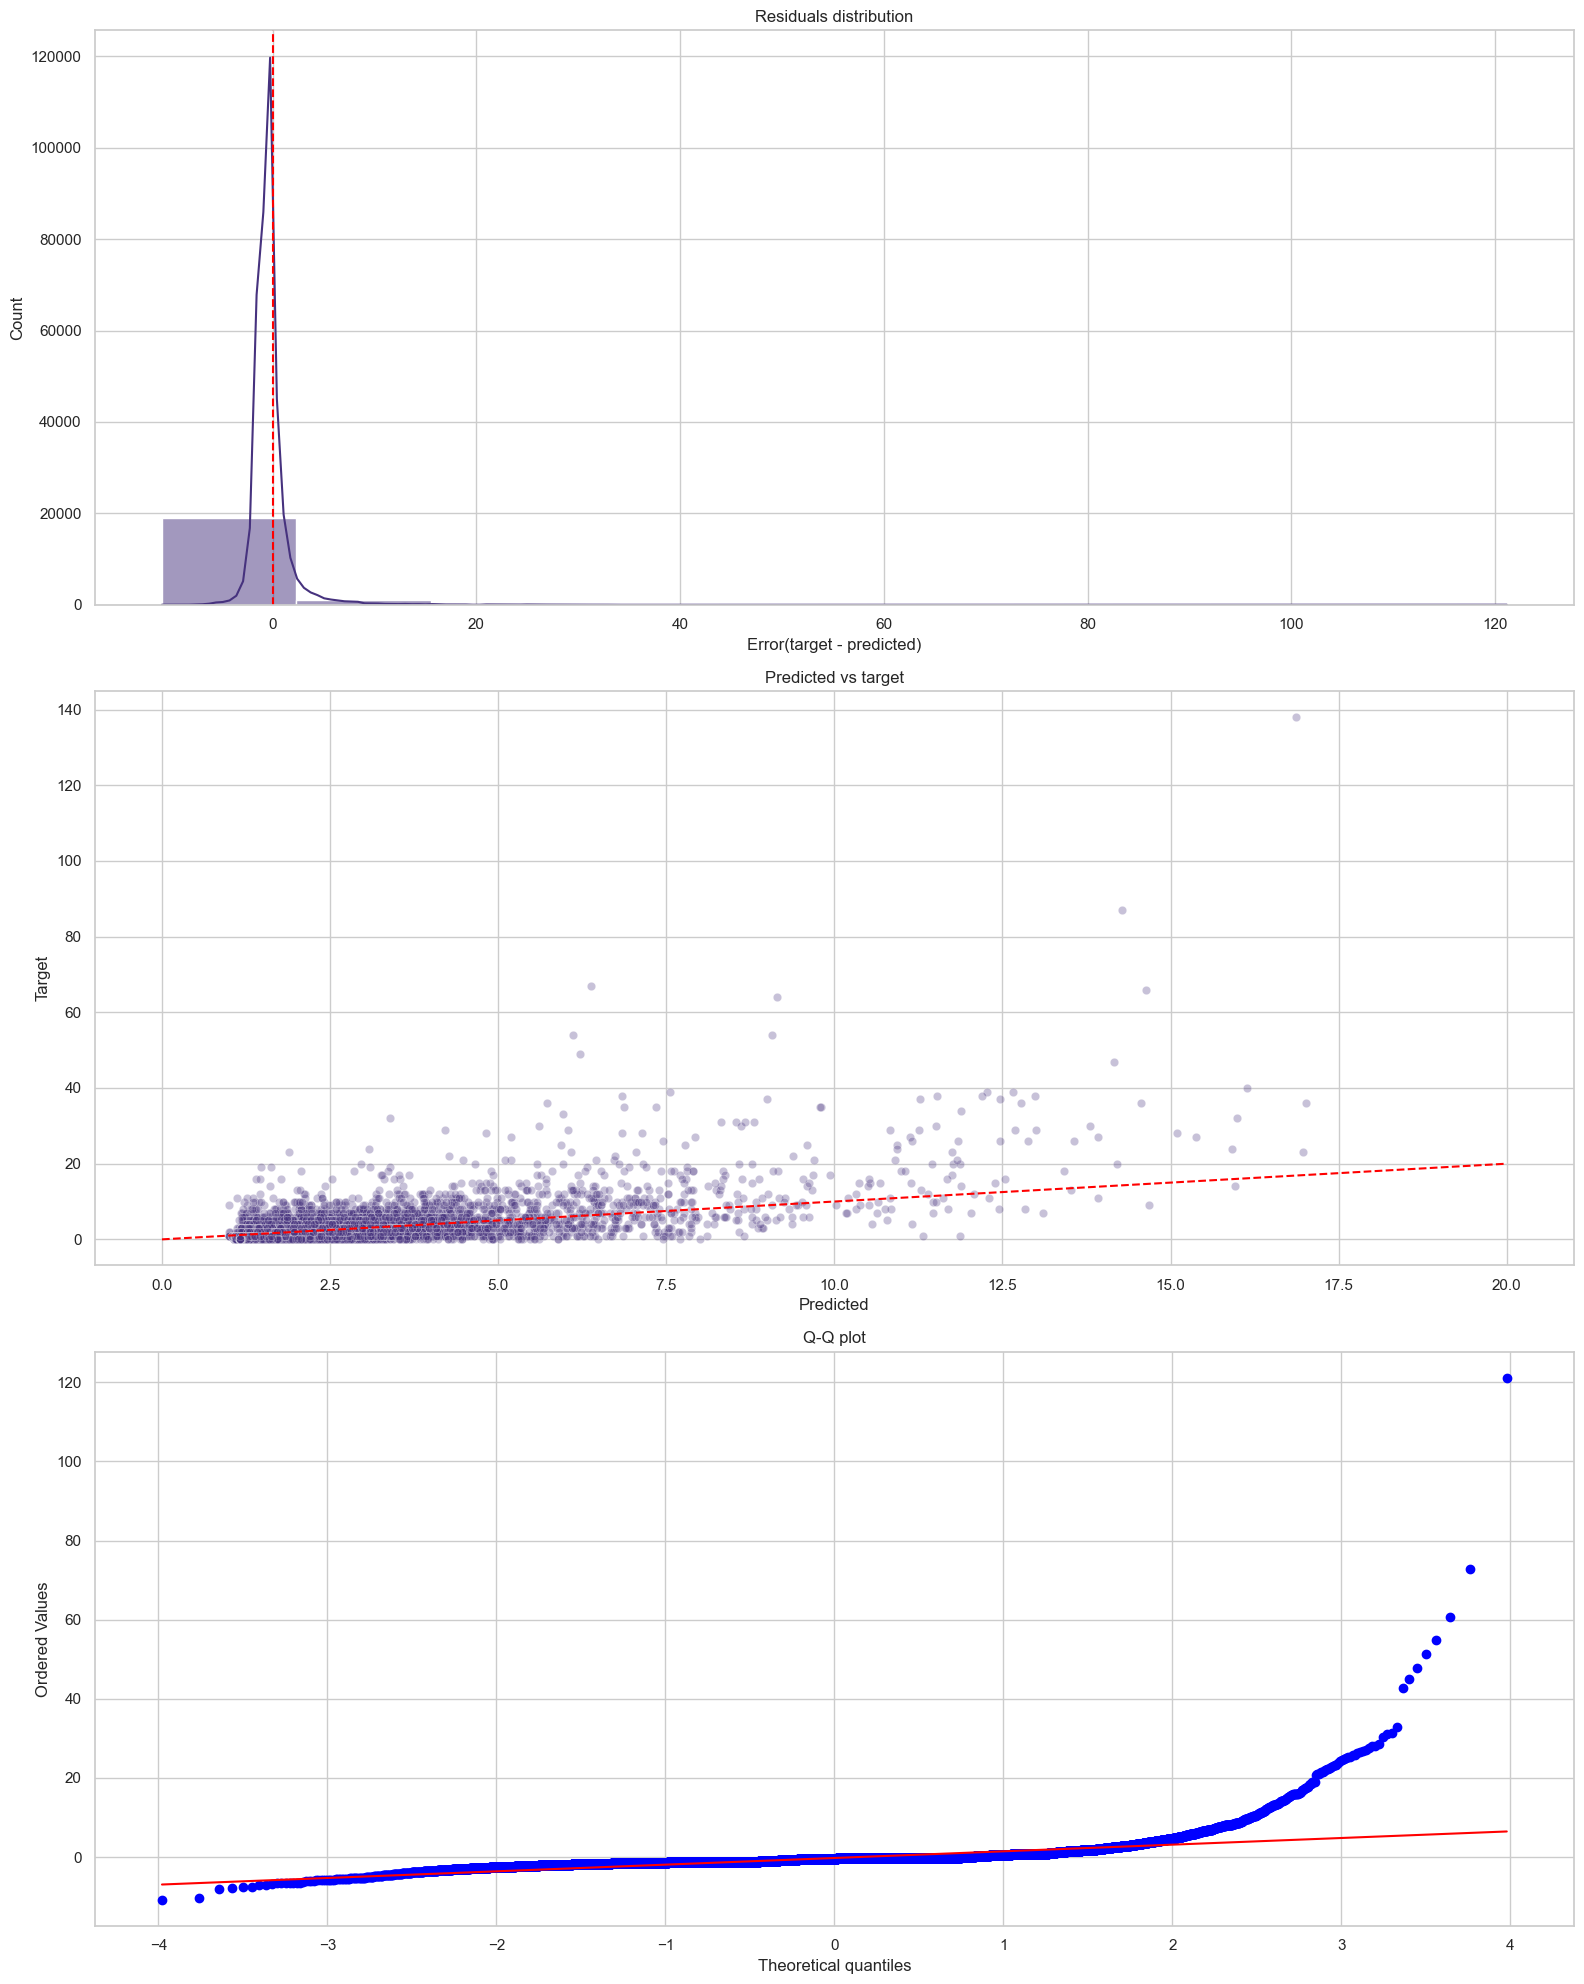

In [62]:
fig, axes = plt.subplots(3,1, figsize=(16,20))

sns.histplot(residuals, bins=10, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residuals distribution")
axes[0].set_xlabel("Error(target - predicted)")

sns.scatterplot(x=predict, y=y_val_array, alpha=0.3, ax=axes[1])
axes[1].plot([0, 20], [0, 20], 'r--')
axes[1].set_title("Predicted vs target")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Target")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

In [63]:
print("=" * 50)
print("МЕТРИКИ")
print("=" * 50)
print(f"RMSE: {root_mean_squared_error(y_val_array, predict):.4f}")
print(f"MAE: {mean_absolute_error(y_val_array, predict):.4f}")
print(f"Mean residual: {residuals.mean():.4f}")
print(f"Std residual: {residuals.std():.4f}")

МЕТРИКИ
RMSE: 2.4800
MAE: 1.1777
Mean residual: -0.2345
Std residual: 2.4689


In [65]:
error_df = pd.DataFrame(
    {
        "actual":y_val_array,
        "predicted":predict,
        "residual":residuals,
        "abs_error":np.abs(residuals),
        "date_block_num":train_df.date_block_num[:20000],
        "shop_id":train_df.shop_id[:20000],
        "item_id":train_df.item_id[:20000]
    }
)

In [66]:
print("\n" + "=" * 50)
print("ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК")
print("=" * 50)

print(error_df.nlargest(10,"abs_error")[["actual", "predicted","residual","shop_id","item_id"]])


ТОП-10 САМЫХ БОЛЬШИХ ОШИБОК
       actual  predicted    residual  shop_id  item_id
15440   138.0  16.867734  121.132266        2     3731
15473    87.0  14.275329   72.724671        2     3733
3233     67.0   6.381928   60.618072        0    14752
4416     64.0   9.142069   54.857931        0    19811
15447    66.0  14.633996   51.366004        2     3732
3559     54.0   6.115889   47.884111        0    16482
6761     54.0   9.065765   44.934235        1    13354
3228     49.0   6.216492   42.783508        0    14730
15483    47.0  14.158685   32.841315        2     3734
3156     39.0   7.556286   31.443714        0    14433



ТОП-5 МАГАЗИНОВ С САМЫМ БОЛЬШИМ RMSE
         mean_error      rmse  count
shop_id                             
0          0.447163  3.071998   4821
1          0.140969  1.841051   3282
2         -0.614297  2.362324  11897


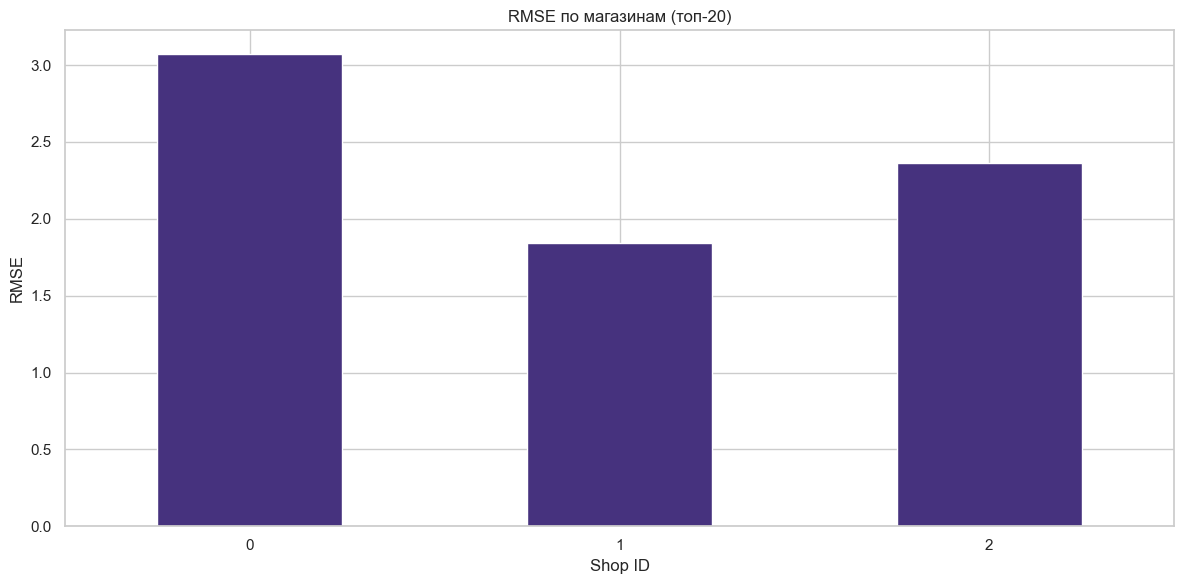

In [103]:
shop_errors = error_df.groupby("shop_id").agg(
    mean_error=('residual', 'mean'),
    rmse=('residual', lambda x: np.sqrt((x**2).mean())),
    count=('shop_id', "count")
).sort_values("mean_error", ascending=False)

print("\n" + "=" * 50)
print("ТОП-5 МАГАЗИНОВ С САМЫМ БОЛЬШИМ RMSE")
print("=" * 50)
print(shop_errors.head(5))

fig, ax = plt.subplots(figsize=(12,6)) 
shop_errors.head(20).plot(y='rmse', kind='bar', ax=ax, legend=False)
ax.set_title('RMSE по магазинам (топ-20)')
ax.set_xlabel('Shop ID')
ax.set_ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


ТОП-5 МЕСЯЦЕВ С САМЫМ БОЛЬШИМ RMSE
                mean_error      rmse  count
date_block_num                             
27               -0.563768  6.304413    397
22               -0.316382  4.639040    405
8                -0.497585  3.550412    352
23                0.066012  3.137539    433
9                -0.723802  2.801047    354


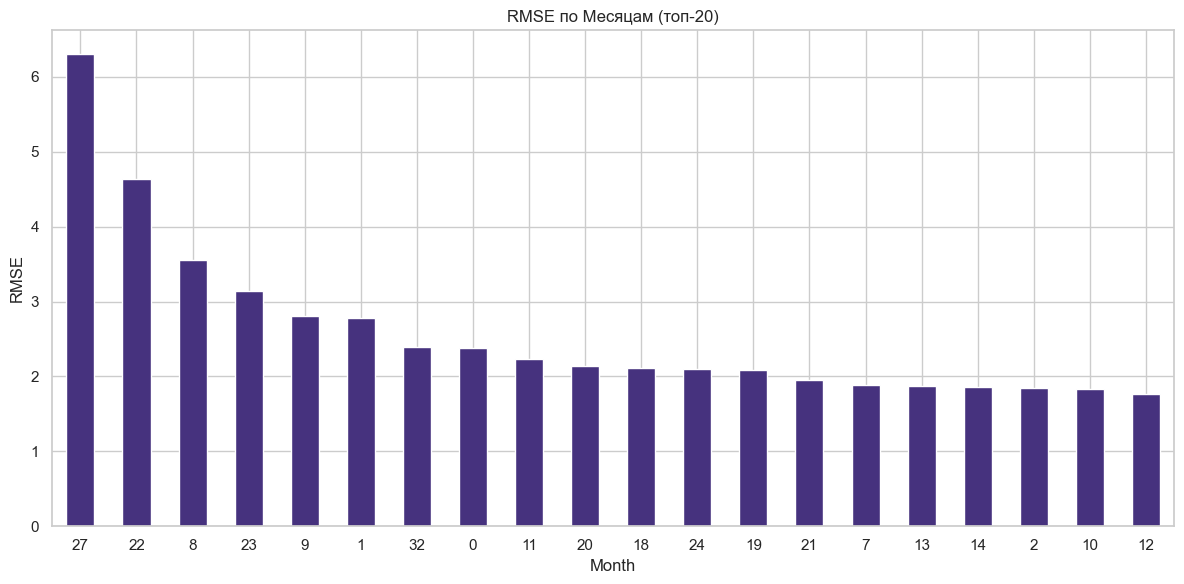

In [104]:
month_errors = error_df.groupby("date_block_num").agg(
    mean_error=("residual","mean"),
    rmse=("residual", lambda x: np.sqrt((x**2).mean())),
    count=("date_block_num","count")
).sort_values("rmse", ascending=False)

print("\n" + "=" * 50)
print("ТОП-5 МЕСЯЦЕВ С САМЫМ БОЛЬШИМ RMSE")
print("=" * 50)
print(month_errors.head(5))

fig, ax = plt.subplots(figsize=(12,6))
month_errors.head(20).plot(y="rmse", kind="bar", ax=ax, legend=False)
ax.set_title('RMSE по Месяцам (топ-20)')
ax.set_xlabel('Month')
ax.set_ylabel('RMSE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()